## 학습목표

1. **정규분포**의 개념과 68-95-99.7 규칙을 이해하고, 품질 관리 기준 설정에 활용할 수 있음
2. **Z-score**를 계산하여 개별 측정값의 이상 여부를 판단할 수 있음
3. 데이터 유형과 비교 상황에 맞는 **적절한 통계 검정 방법**을 선택할 수 있음
4. **t-검정**으로 두 생산 라인의 품질 차이를 통계적으로 검정할 수 있음

## 실습 데이터 소개

본 강의에서는 다음 공공데이터를 활용함:

| 데이터명 | 출처 | 내용 | 활용 목적 |
|---------|------|------|----------|
| UCI SECOM Dataset | UCI Machine Learning Repository | 반도체 제조공정 센서 데이터 (1,567건, 591개 특성) | 정규분포 검정, 이상치 탐지, 품질 예측 |
| 전국산업단지현황통계 | 공공데이터포털 (한국산업단지공단) | 시도별 생산액, 수출액, 고용 현황 | 그룹 비교, t-검정 실습 |

## 실습 환경 설정

In [37]:
# 필수 라이브러리 임포트
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings

# 경고 메시지 숨김
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (운영체제에 따라 선택)
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지
plt.rcParams['figure.figsize'] = (10, 6)    # 기본 그래프 크기
plt.rcParams['font.size'] = 11              # 기본 폰트 크기

# 시드 고정 (재현성 확보)
np.random.seed(42)

print("실습 환경 설정 완료")
print(f"   - NumPy 버전: {np.__version__}")
print(f"   - Pandas 버전: {pd.__version__}")

실습 환경 설정 완료
   - NumPy 버전: 2.4.0
   - Pandas 버전: 2.3.3


## 공공데이터 로드: UCI SECOM 반도체 제조 데이터

UCI SECOM 데이터셋은 반도체 웨이퍼 제조 공정에서 수집된 센서 데이터임. 590개의 센서 측정값과 품질 검사 결과(합격/불합격)로 구성되어 있음.

### 데이터 출처 및 라이선스
- **출처**: UCI Machine Learning Repository (https://archive.ics.uci.edu/dataset/179/secom)
- **제공자**: Michael McCann, Adrian Johnston
- **라이선스**: CC BY 4.0
- **DOI**: 10.24432/C54305

In [38]:
import urllib.request
import zipfile
import os

# 데이터 디렉토리 설정
data_dir = './secom_data'
os.makedirs(data_dir, exist_ok=True)

# 데이터 다운로드
zip_path = os.path.join(data_dir, 'secom.zip')
if not os.path.exists(os.path.join(data_dir, 'secom.data')):
    print("UCI SECOM 데이터셋 다운로드 중...")
    url = "https://archive.ics.uci.edu/static/public/179/secom.zip"
    urllib.request.urlretrieve(url, zip_path)
    
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(data_dir)
    print("다운로드 완료")

# 센서 데이터 로드
X = pd.read_csv(os.path.join(data_dir, 'secom.data'), 
                sep=r'\s+', header=None, na_values='NaN')
X.columns = [f'sensor_{i}' for i in range(X.shape[1])]

# 라벨 데이터 로드
labels_df = pd.read_csv(os.path.join(data_dir, 'secom_labels.data'), 
                        sep=r'\s+', header=None, names=['quality', 'timestamp'])
y = labels_df['quality']

In [39]:
print("=" * 60)
print("         UCI SECOM 반도체 제조 데이터셋 개요")
print("=" * 60)
print(f"\n데이터 형태: {X.shape[0]}개 샘플, {X.shape[1]}개 특성")
print(f"품질 검사 결과 분포:")
print(f"   - 합격 (-1): {(y.values == -1).sum()}건")
print(f"   - 불합격 (1): {(y.values == 1).sum()}건")
print(f"   - 불합격률: {(y.values == 1).sum() / len(y) * 100:.2f}%")

# 결측치 현황
missing_ratio = X.isnull().sum().sum() / (X.shape[0] * X.shape[1]) * 100
print(f"\n결측치 비율: {missing_ratio:.2f}%")

         UCI SECOM 반도체 제조 데이터셋 개요

데이터 형태: 1567개 샘플, 590개 특성
품질 검사 결과 분포:
   - 합격 (-1): 1463건
   - 불합격 (1): 104건
   - 불합격률: 6.64%

결측치 비율: 4.54%


In [40]:
# 분석에 사용할 주요 센서 특성 선택 (결측치가 적은 상위 20개)
missing_counts = X.isnull().sum()
selected_features = missing_counts.nsmallest(20).index.tolist()

# 선택된 특성으로 데이터프레임 구성
df_secom = X[selected_features].copy()
df_secom['quality'] = y.values.flatten()
df_secom['quality_label'] = df_secom['quality'].map({-1: '합격', 1: '불합격'})

# 결측치 처리 (평균값 대체)
df_secom[selected_features] = df_secom[selected_features].fillna(
    df_secom[selected_features].mean()
)

print("전처리 완료: 주요 센서 20개 특성 선택, 결측치 평균값 대체")
print(f"\n선택된 센서 특성: {selected_features[:5]}... (외 15개)")
print(f"최종 데이터 형태: {df_secom.shape}")

전처리 완료: 주요 센서 20개 특성 선택, 결측치 평균값 대체

선택된 센서 특성: ['sensor_20', 'sensor_86', 'sensor_87', 'sensor_88', 'sensor_113']... (외 15개)
최종 데이터 형태: (1567, 22)


# 1. 정규분포의 개념과 68-95-99.7 규칙

## 1.1 확률분포를 학습해야 하는 이유

### 제조 현장의 질문들

제조 현장에서는 매일 수많은 데이터가 발생함. 이 데이터를 올바르게 해석하려면 **확률분포**에 대한 이해가 필수적임.

| 상황 | 질문 | 필요한 지식 |
|------|------|------------|
| 품질 측정 | "이 측정값이 정상 범위인가?" | 정규분포, Z-score |
| 라인 비교 | "두 라인의 품질 차이가 실제로 있는가?" | t-검정 |
| 생산 관리 | "오늘 생산량이 이상하게 높은데, 정말 이상한 건가?" | 이상치 탐지 |
| 공정 변경 | "새 공정이 불량률을 정말 줄였을까?" | 가설검정 |

### 데이터 기반 의사결정의 중요성

제조업에서 데이터 기반 의사결정이 중요한 이유는 다음과 같음:

- **예측**: 앞으로 어떤 값이 나올지 확률적으로 예상 가능함
- **판단**: 관측값이 정상인지 이상인지 객관적으로 판단 가능함
- **검증**: 변화나 차이가 우연인지 실제인지 통계적으로 검증 가능함

## 1.2 확률분포의 정의

### 기본 개념

**확률분포(Probability Distribution)** 란 확률변수가 특정 값을 가질 확률을 나타내는 함수임.

### 수학적 정의

확률변수 $X$에 대해:

$$P(a \leq X \leq b) = \int_a^b f(x) \, dx$$

여기서 $f(x)$는 **확률밀도함수(PDF: Probability Density Function)** 이며, 다음 조건을 만족함:

1. **비음성 조건**: $f(x) \geq 0$ (모든 $x$에 대해)
2. **정규화 조건**: $\int_{-\infty}^{\infty} f(x) \, dx = 1$ (전체 확률의 합은 1)

### 확률분포의 종류

#### 이산형 확률분포 (Discrete Probability Distribution)

확률변수가 셀 수 있는 값을 가지는 경우에 해당함.

| 분포 | 확률질량함수 | 예시 |
|------|-------------|------|
| **이항분포** | $P(X=k) = \binom{n}{k} p^k (1-p)^{n-k}$ | 100개 중 불량품 개수 |
| **포아송분포** | $P(X=k) = \frac{\lambda^k e^{-\lambda}}{k!}$ | 시간당 결함 발생 수 |

#### 연속형 확률분포 (Continuous Probability Distribution)

확률변수가 연속적인 값을 가지는 경우에 해당함.

| 분포 | 확률밀도함수 | 예시 |
|------|-------------|------|
| **정규분포** | $f(x) = \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{(x-\mu)^2}{2\sigma^2}}$ | 제품 무게, 치수 |
| **균등분포** | $f(x) = \frac{1}{b-a}$ (단, $a \leq x \leq b$) | 무작위 추출 |
| **지수분포** | $f(x) = \lambda e^{-\lambda x}$ (단, $x \geq 0$) | 고장 발생 간격 |

## 1.3 정규분포 (Normal Distribution)

### 정규분포의 정의

정규분포는 자연과 산업에서 가장 널리 관찰되는 확률분포로, **가우스 분포(Gaussian Distribution)** 라고도 함.

#### 확률밀도함수

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

#### 표기법

$$X \sim N(\mu, \sigma^2)$$

- $\mu$ (뮤, mu): **평균** - 분포의 중심 위치
- $\sigma$ (시그마, sigma): **표준편차** - 분포의 퍼짐 정도
- $\sigma^2$: **분산** - 표준편차의 제곱

### 정규분포의 특성

1. **대칭성**: 평균 $\mu$를 중심으로 좌우 대칭인 종 모양(bell curve)임
2. **단봉성**: 평균에서 최댓값을 가지며, 하나의 봉우리만 존재함
3. **점근성**: 양 끝은 x축에 점근하지만 절대 닿지 않음
4. **완전 정의**: 평균($\mu$)과 표준편차($\sigma$) 두 매개변수로 완전히 정의됨

### 정규분포의 적률(Moments)

| 적률 | 공식 | 정규분포 값 |
|------|------|------------|
| 평균 (1차 적률) | $E[X] = \mu$ | $\mu$ |
| 분산 (2차 중심적률) | $Var(X) = E[(X-\mu)^2]$ | $\sigma^2$ |
| 왜도 (3차 표준적률) | $\gamma_1 = E\left[\left(\frac{X-\mu}{\sigma}\right)^3\right]$ | 0 (대칭) |
| 첨도 (4차 표준적률) | $\gamma_2 = E\left[\left(\frac{X-\mu}{\sigma}\right)^4\right] - 3$ | 0 (정규 기준) |

한번, UCI SECOM 데이터의 센서 측정값이 정규분포를 따르는지 검정해 보자

In [41]:
# 첫 번째 센서 특성 선택
sensor_col = selected_features[0]
sensor_data = df_secom[sensor_col].dropna()

print(f"분석 대상 센서: {sensor_col}")
print(f"데이터 개수: {len(sensor_data)}개")

# 기초 통계량 계산
mean_val = np.mean(sensor_data)
std_val = np.std(sensor_data)
median_val = np.median(sensor_data)
skewness = stats.skew(sensor_data)
kurtosis = stats.kurtosis(sensor_data)

print(f"\n기초 통계량:")
print(f"   평균: {mean_val:.4f}")
print(f"   표준편차: {std_val:.4f}")
print(f"   중앙값: {median_val:.4f}")
print(f"   왜도: {skewness:.4f} (0이면 대칭)")
print(f"   첨도: {kurtosis:.4f} (0이면 정규분포)")

분석 대상 센서: sensor_20
데이터 개수: 1567개

기초 통계량:
   평균: 1.4051
   표준편차: 0.0167
   중앙값: 1.4060
   왜도: -2.8024 (0이면 대칭)
   첨도: 30.5071 (0이면 정규분포)


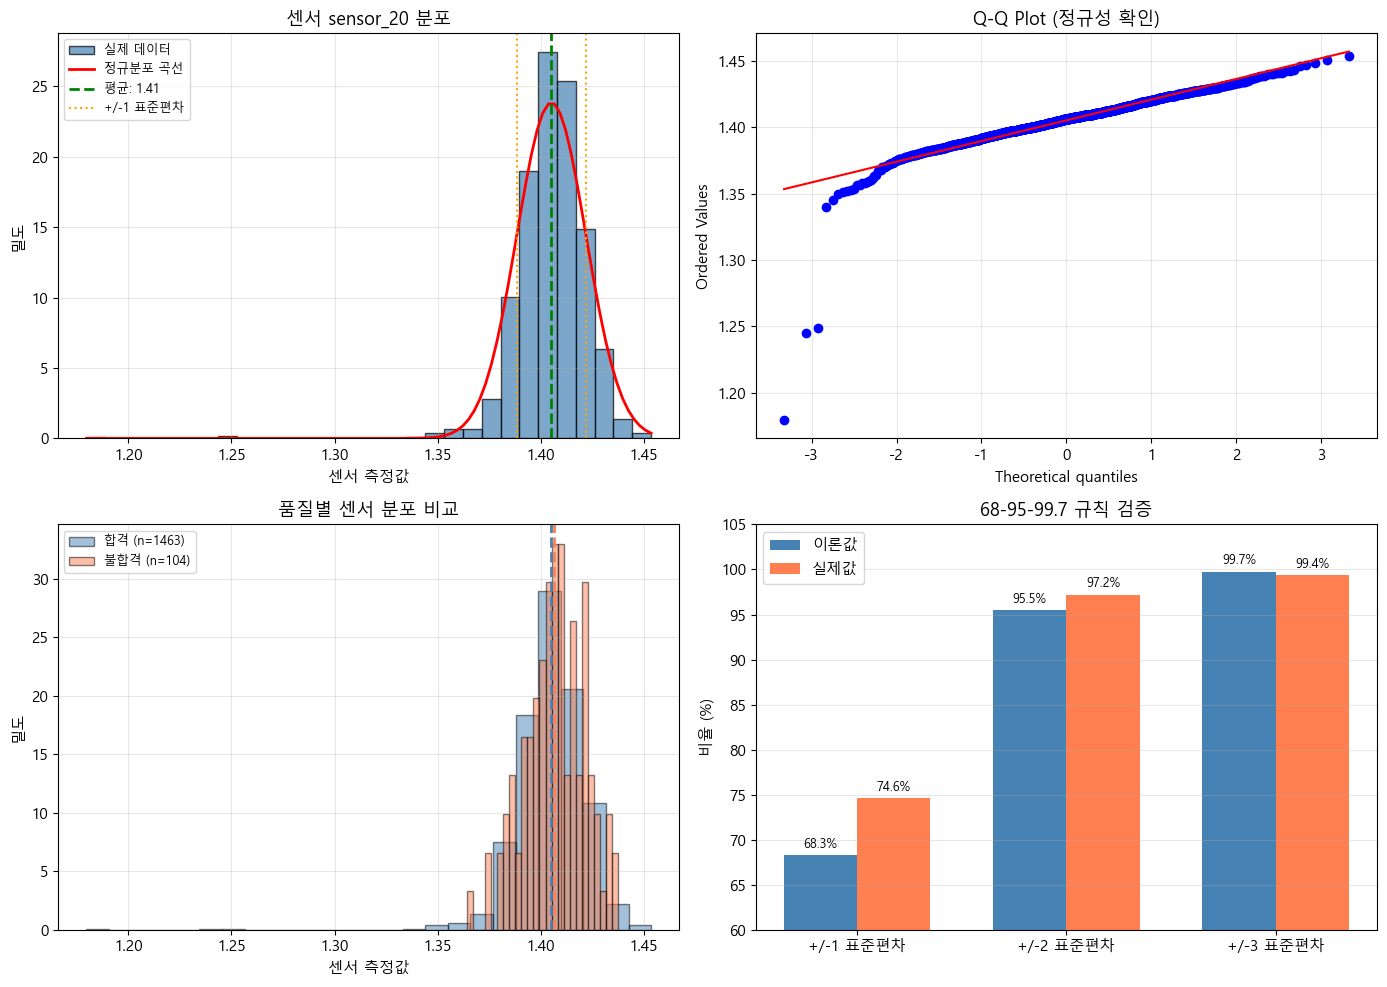


정규성 검정 (Shapiro-Wilk Test)
검정통계량: 0.8656
p-value: 0.000000
결론: p <= 0.05이므로 정규분포를 따르지 않음


In [42]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. 히스토그램과 정규분포 곡선
ax1 = axes[0, 0]
n, bins, patches = ax1.hist(sensor_data, bins=30, density=True, 
                             alpha=0.7, color='steelblue', edgecolor='black',
                             label='실제 데이터')

# 이론적 정규분포 곡선
x = np.linspace(sensor_data.min(), sensor_data.max(), 100)
y = stats.norm.pdf(x, mean_val, std_val)
ax1.plot(x, y, 'r-', linewidth=2, label='정규분포 곡선')

# 평균과 표준편차 선
ax1.axvline(mean_val, color='green', linestyle='--', linewidth=2, 
            label=f'평균: {mean_val:.2f}')
ax1.axvline(mean_val - std_val, color='orange', linestyle=':', linewidth=1.5)
ax1.axvline(mean_val + std_val, color='orange', linestyle=':', linewidth=1.5,
            label=f'+/-1 표준편차')

ax1.set_xlabel('센서 측정값', fontsize=11)
ax1.set_ylabel('밀도', fontsize=11)
ax1.set_title(f'센서 {sensor_col} 분포', fontsize=13)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# 2. Q-Q Plot (Quantile-Quantile Plot)
ax2 = axes[0, 1]
stats.probplot(sensor_data, dist="norm", plot=ax2)
ax2.set_title('Q-Q Plot (정규성 확인)', fontsize=13)
ax2.grid(True, alpha=0.3)

# 3. 품질별 분포 비교 (합격 vs 불합격)
ax3 = axes[1, 0]
pass_data = df_secom[df_secom['quality'] == -1][sensor_col]
fail_data = df_secom[df_secom['quality'] == 1][sensor_col]

ax3.hist(pass_data, bins=25, alpha=0.5, color='steelblue', 
         label=f'합격 (n={len(pass_data)})', density=True, edgecolor='black')
ax3.hist(fail_data, bins=25, alpha=0.5, color='coral',
         label=f'불합격 (n={len(fail_data)})', density=True, edgecolor='black')
ax3.axvline(pass_data.mean(), color='steelblue', linestyle='--', linewidth=2)
ax3.axvline(fail_data.mean(), color='coral', linestyle='--', linewidth=2)
ax3.set_xlabel('센서 측정값', fontsize=11)
ax3.set_ylabel('밀도', fontsize=11)
ax3.set_title('품질별 센서 분포 비교', fontsize=13)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# 4. 68-95-99.7 규칙 검증
ax4 = axes[1, 1]
categories = ['+/-1 표준편차', '+/-2 표준편차', '+/-3 표준편차']
theoretical = [68.27, 95.45, 99.73]
actual = []

for k in [1, 2, 3]:
    in_range = np.sum((sensor_data >= mean_val - k*std_val) & 
                       (sensor_data <= mean_val + k*std_val))
    actual.append(in_range / len(sensor_data) * 100)

x_pos = np.arange(len(categories))
width = 0.35

bars1 = ax4.bar(x_pos - width/2, theoretical, width, label='이론값', color='steelblue')
bars2 = ax4.bar(x_pos + width/2, actual, width, label='실제값', color='coral')

ax4.set_ylabel('비율 (%)', fontsize=11)
ax4.set_title('68-95-99.7 규칙 검증', fontsize=13)
ax4.set_xticks(x_pos)
ax4.set_xticklabels(categories)
ax4.legend()
ax4.set_ylim(60, 105)
ax4.grid(True, alpha=0.3, axis='y')

# 막대 위에 값 표시
for bar, val in zip(bars1, theoretical):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
for bar, val in zip(bars2, actual):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# 정규성 검정: Shapiro-Wilk Test
# 표본 크기가 5000 초과 시 일부 샘플링
test_sample = sensor_data.sample(min(5000, len(sensor_data)), random_state=42)
stat, p_value = stats.shapiro(test_sample)

print("\n정규성 검정 (Shapiro-Wilk Test)")
print("=" * 50)
print(f"검정통계량: {stat:.4f}")
print(f"p-value: {p_value:.6f}")
if p_value > 0.05:
    print("결론: p > 0.05이므로 정규분포를 따른다고 볼 수 있음")
else:
    print("결론: p <= 0.05이므로 정규분포를 따르지 않음")

## 1.5 68-95-99.7 규칙 (경험적 규칙)

### 규칙의 정의

정규분포에서 데이터가 평균으로부터 일정 표준편차 범위 내에 포함될 확률은 다음과 같음:

| 범위 | 확률 | 의미 |
|------|------|------|
| $\mu \pm 1\sigma$ | **68.27%** | 약 2/3의 데이터 |
| $\mu \pm 2\sigma$ | **95.45%** | 거의 모든 데이터 |
| $\mu \pm 3\sigma$ | **99.73%** | 사실상 전체 데이터 |

### 수학적 유도

정규분포의 누적분포함수(CDF)를 이용하여 계산함:

$$P(\mu - k\sigma \leq X \leq \mu + k\sigma) = 2\Phi(k) - 1$$

여기서 $\Phi(k)$는 표준정규분포의 CDF임.

| $k$ | $\Phi(k)$ | $2\Phi(k) - 1$ |
|-----|-----------|----------------|
| 1 | 0.8413 | 0.6827 (68.27%) |
| 2 | 0.9772 | 0.9545 (95.45%) |
| 3 | 0.9987 | 0.9973 (99.73%) |

### 품질 관리에서의 적용

68-95-99.7 규칙은 **Six Sigma(6 시그마) 품질 관리**의 기초가 됨.

| 범위 | 품질 관리 관점 | 조치 |
|------|---------------|------|
| $\mu \pm 1\sigma$ | 일상적인 변동 | 정상 운영 |
| $\mu \pm 2\sigma$ | 주의 범위 | 모니터링 강화 |
| $\mu \pm 3\sigma$ | 관리 한계 | 이상치로 판단, 즉시 조사 |

**핵심**: $\pm 3\sigma$ 밖에 있는 데이터는 **0.27%** (약 370개 중 1개)에 불과함. 이 범위를 벗어나면 **이상치로 의심**해야 함.

## 1.6 중심극한정리 (Central Limit Theorem)

### 정의

모집단이 평균 $\mu$, 분산 $\sigma^2$을 가질 때, 크기 $n$인 표본의 평균 $\bar{X}$는 다음을 따름:

$$\bar{X} \sim N\left(\mu, \frac{\sigma^2}{n}\right) \quad \text{as } n \to \infty$$

표준화하면:

$$Z = \frac{\bar{X} - \mu}{\sigma / \sqrt{n}} \sim N(0, 1)$$

### 의의

- 원래 분포가 무엇이든, 표본 크기가 충분히 크면(일반적으로 n >= 30) 표본평균은 정규분포를 따름
- 이로 인해 정규분포 기반의 통계적 추론이 광범위하게 적용 가능함

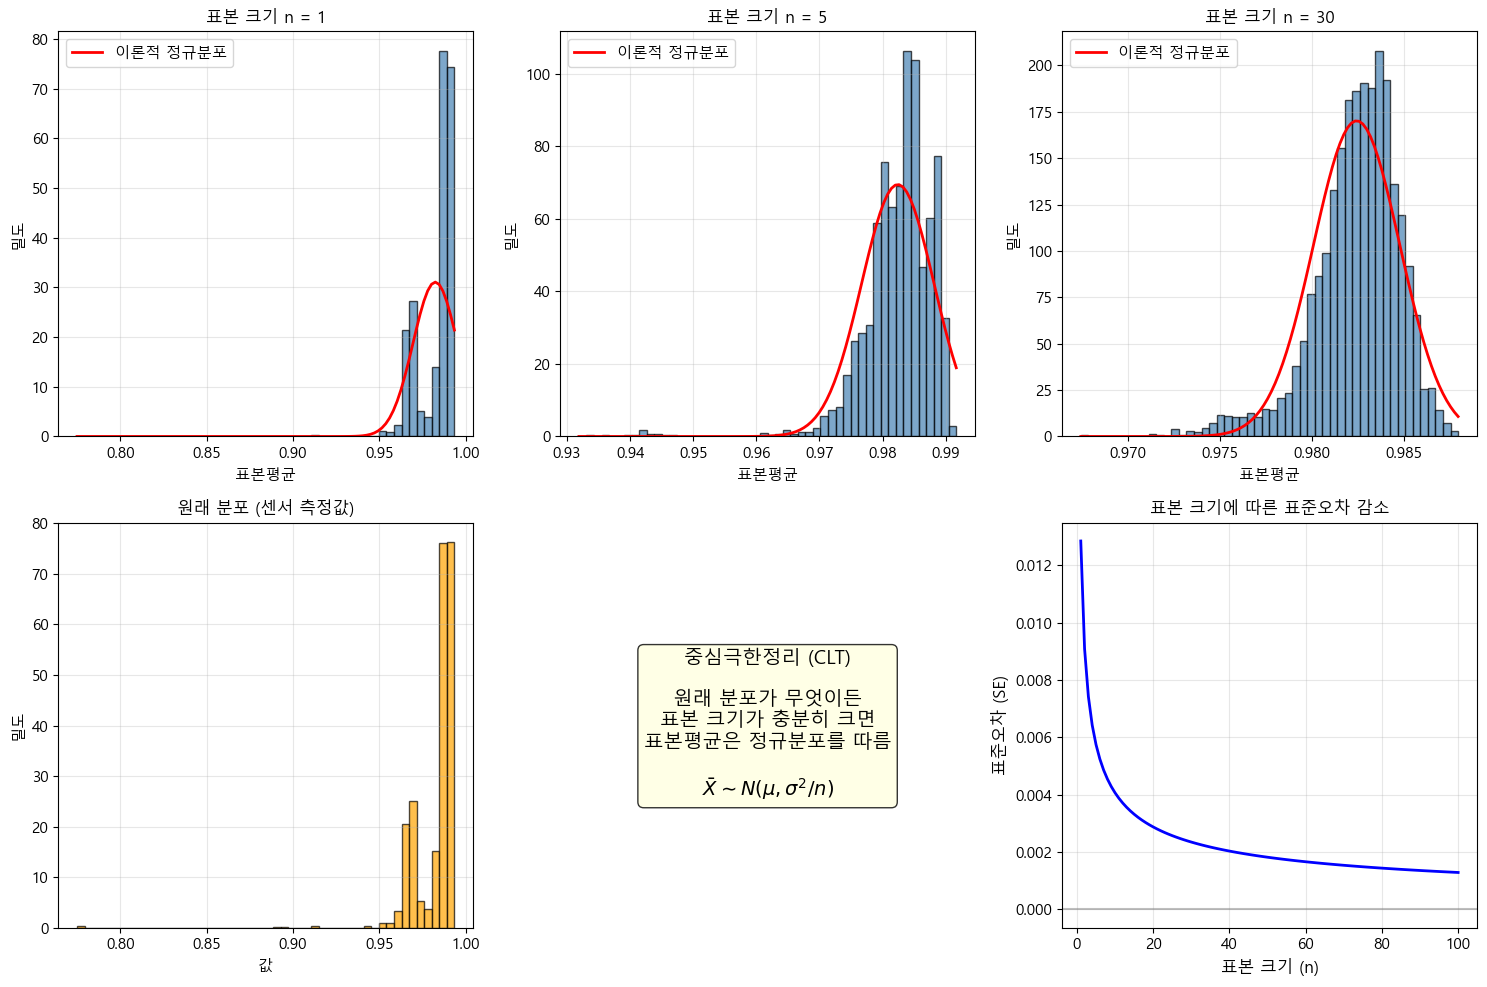

중심극한정리의 의미:
   - 원래 분포가 비정규분포임에도 불구하고
   - 표본 크기가 커질수록 표본평균의 분포는 종 모양(정규분포)에 가까워짐
   - n=30 정도면 대부분의 경우 정규분포로 근사 가능함


In [43]:
# 중심극한정리 시각화: SECOM 데이터 활용
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 원래 분포 (센서 데이터 - 정규분포가 아닐 수 있음)
original_data = df_secom[selected_features[2]].dropna().values

# 표본 크기별 표본평균의 분포
sample_sizes = [1, 5, 30]
num_samples = 5000

for idx, n in enumerate(sample_sizes):
    # 표본평균 계산
    sample_means = [np.mean(np.random.choice(original_data, n, replace=True)) 
                    for _ in range(num_samples)]
    
    # 히스토그램
    axes[0, idx].hist(sample_means, bins=50, density=True, 
                       alpha=0.7, color='steelblue', edgecolor='black')
    
    # 이론적 정규분포 곡선
    mu = np.mean(original_data)
    sigma = np.std(original_data) / np.sqrt(n)
    x = np.linspace(min(sample_means), max(sample_means), 100)
    axes[0, idx].plot(x, stats.norm.pdf(x, mu, sigma), 
                      'r-', linewidth=2, label='이론적 정규분포')
    
    axes[0, idx].set_title(f'표본 크기 n = {n}', fontsize=12)
    axes[0, idx].set_xlabel('표본평균')
    axes[0, idx].set_ylabel('밀도')
    axes[0, idx].legend()
    axes[0, idx].grid(True, alpha=0.3)

# 원래 분포
axes[1, 0].hist(original_data, bins=50, density=True, 
                 alpha=0.7, color='orange', edgecolor='black')
axes[1, 0].set_title('원래 분포 (센서 측정값)', fontsize=12)
axes[1, 0].set_xlabel('값')
axes[1, 0].set_ylabel('밀도')
axes[1, 0].grid(True, alpha=0.3)

# 중심극한정리 설명
axes[1, 1].text(0.5, 0.5, 
    '중심극한정리 (CLT)\n\n'
    '원래 분포가 무엇이든\n'
    '표본 크기가 충분히 크면\n'
    '표본평균은 정규분포를 따름\n\n'
    r'$\bar{X} \sim N(\mu, \sigma^2/n)$',
    ha='center', va='center', fontsize=14,
    transform=axes[1, 1].transAxes,
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
axes[1, 1].axis('off')

# 표본 크기와 표준오차의 관계
n_values = np.arange(1, 101)
se_values = np.std(original_data) / np.sqrt(n_values)
axes[1, 2].plot(n_values, se_values, 'b-', linewidth=2)
axes[1, 2].set_xlabel('표본 크기 (n)', fontsize=12)
axes[1, 2].set_ylabel('표준오차 (SE)', fontsize=12)
axes[1, 2].set_title('표본 크기에 따른 표준오차 감소', fontsize=12)
axes[1, 2].grid(True, alpha=0.3)
axes[1, 2].axhline(y=0, color='gray', linestyle='-', alpha=0.5)

plt.tight_layout()
plt.show()

print("중심극한정리의 의미:")
print("   - 원래 분포가 비정규분포임에도 불구하고")
print("   - 표본 크기가 커질수록 표본평균의 분포는 종 모양(정규분포)에 가까워짐")
print("   - n=30 정도면 대부분의 경우 정규분포로 근사 가능함")

### 핵심 개념

| 개념 | 정의 | 활용 |
|------|------|------|
| **확률분포** | 확률변수가 특정 값을 가질 확률의 패턴 | 데이터 예측 및 판단의 기초 |
| **정규분포** | $N(\mu, \sigma^2)$, 종 모양의 대칭 분포 | 품질 측정값 모델링 |
| **68-95-99.7 규칙** | 표준편차별 데이터 포함 비율 | 관리 한계 설정 |
| **중심극한정리** | 표본평균은 정규분포로 수렴 | 통계적 추론의 근거 |

### 핵심 공식

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

### 품질 관리 적용

- **평균 +/- 1 표준편차**: 일상적인 변동으로 정상 운영
- **평균 +/- 2 표준편차**: 주의 범위로 모니터링 강화
- **평균 +/- 3 표준편차**: 관리 한계로 이상치 판단, 즉시 조사

# Z-score를 활용한 이상치 탐지

## 2.1 이상치(Outlier)의 정의

**이상치(Outlier)** 란 다른 데이터와 현저하게 동떨어진 값으로, 데이터의 일반적인 패턴에서 벗어난 관측치임.

### 제조업에서의 이상치 유형

| 상황 | 이상치 예시 | 가능한 원인 |
|------|------------|------------|
| 생산량 | 평소 1,200개, 오늘 1,500개 | 특근, 측정 오류, 기록 실수, 설비 개선 |
| 품질 | 평균 500g, 측정 480g | 원료 문제, 설비 이상, 측정 장비 오류 |
| 불량률 | 평소 2%, 오늘 8% | 공정 이상, 원자재 불량, 작업자 실수 |
| 센서값 | 정상 범위 초과 | 센서 고장, 공정 이상, 환경 변화 |

### 이상치 탐지의 중요성

이상치는 문제의 신호일 수 있음:
- 빠른 발견을 통해 빠른 대응이 가능함
- 품질 문제의 조기 경보 역할을 함
- 공정 이상을 감지하는 데 활용됨

## 2.2 Z-score (표준점수)

### 정의

**Z-score(표준점수)** 는 개별 관측값이 평균으로부터 몇 표준편차 떨어져 있는지를 나타내는 표준화된 점수임.

### 공식

$$Z = \frac{X - \mu}{\sigma}$$

또는 표본의 경우:

$$Z = \frac{X - \bar{X}}{s}$$

여기서:
- $X$: 개별 관측값
- $\mu$ (또는 $\bar{X}$): 모평균 (또는 표본평균)
- $\sigma$ (또는 $s$): 모표준편차 (또는 표본표준편차)

### Z-score의 의미

| Z-score | 의미 | 백분위 |
|---------|------|--------|
| Z = 0 | 평균과 동일 | 50% |
| Z = 1 | 평균보다 1 표준편차 위 | 84.1% |
| Z = 2 | 평균보다 2 표준편차 위 | 97.7% |
| Z = 3 | 평균보다 3 표준편차 위 | 99.87% |
| Z = -1 | 평균보다 1 표준편차 아래 | 15.9% |
| Z = -2 | 평균보다 2 표준편차 아래 | 2.3% |
| Z = -3 | 평균보다 3 표준편차 아래 | 0.13% |

### 이상치 판단 기준

| Z-score 범위 | 비율 | 해석 | 조치 |
|-------------|------|------|------|
| 절대값 Z <= 1 | 68% | 정상 | 문제 없음 |
| 1 < 절대값 Z <= 2 | 27% | 주의 | 모니터링 |
| 2 < 절대값 Z <= 3 | 4.3% | 경고 | 점검 필요 |
| **절대값 Z > 3** | **0.3%** | **이상치** | **즉시 조사** |

## UCI SECOM 데이터에서 Z-score 기반 이상치를 탐지해 보자

In [44]:
def detect_outliers_zscore(data, threshold=2):
    """
    Z-score 기반 이상치 탐지 함수
    
    Parameters
    ----------
    data : array-like
        분석할 데이터 배열
    threshold : float, default=2
        이상치 판단 Z-score 임계값
        
    Returns
    -------
    outlier_mask : ndarray of bool
        이상치 여부 (True: 이상치)
    z_scores : ndarray
        각 데이터의 Z-score
    stats_dict : dict
        통계량 정보 (mean, std, n_outliers)
    """
    data = np.array(data)
    mean = np.mean(data)
    std = np.std(data)
    
    # Z-score 계산
    z_scores = (data - mean) / std
    
    # 이상치 마스크
    outlier_mask = np.abs(z_scores) > threshold
    
    # 통계 정보
    stats_dict = {
        'mean': mean,
        'std': std,
        'threshold': threshold,
        'n_total': len(data),
        'n_outliers': np.sum(outlier_mask),
        'outlier_ratio': np.sum(outlier_mask) / len(data) * 100
    }
    
    return outlier_mask, z_scores, stats_dict


# SECOM 데이터에 적용
sensor_col = selected_features[0]
sensor_values = df_secom[sensor_col].values

outlier_mask, z_scores, stats_info = detect_outliers_zscore(sensor_values, threshold=2)

print("SECOM 센서 데이터 이상치 탐지 결과")
print("=" * 60)
print(f"분석 센서: {sensor_col}")
print(f"전체 데이터 수: {stats_info['n_total']}개")
print(f"평균: {stats_info['mean']:.4f}")
print(f"표준편차: {stats_info['std']:.4f}")
print(f"이상치 기준: |Z| > {stats_info['threshold']}")
print(f"이상치 개수: {stats_info['n_outliers']}개 ({stats_info['outlier_ratio']:.2f}%)")

SECOM 센서 데이터 이상치 탐지 결과
분석 센서: sensor_20
전체 데이터 수: 1567개
평균: 1.4051
표준편차: 0.0167
이상치 기준: |Z| > 2
이상치 개수: 44개 (2.81%)


In [45]:
def multivariate_outlier_analysis(df, columns, threshold=2):
    """
    다변량 데이터의 이상치 분석
    
    Parameters
    ----------
    df : DataFrame
        분석할 데이터프레임
    columns : list
        분석할 수치형 컬럼 목록
    threshold : float
        Z-score 임계값
        
    Returns
    -------
    result_df : DataFrame
        이상치 분석 결과가 추가된 데이터프레임
    summary : dict
        분석 요약
    """
    result_df = df.copy()
    outlier_counts = {}
    
    for col in columns:
        # Z-score 계산
        z_col = f'{col}_Z'
        mean_val = df[col].mean()
        std_val = df[col].std()
        result_df[z_col] = (df[col] - mean_val) / std_val
        
        # 이상치 플래그
        outlier_col = f'{col}_outlier'
        result_df[outlier_col] = np.abs(result_df[z_col]) > threshold
        
        outlier_counts[col] = result_df[outlier_col].sum()
    
    # 하나라도 이상치인 행
    outlier_cols = [f'{col}_outlier' for col in columns]
    result_df['any_outlier'] = result_df[outlier_cols].any(axis=1)
    
    summary = {
        'total_rows': len(df),
        'outlier_counts': outlier_counts,
        'any_outlier_count': result_df['any_outlier'].sum(),
        'threshold': threshold
    }
    
    return result_df, summary


# 분석 실행 (상위 10개 센서)
analysis_cols = selected_features[:10]
result_df, summary = multivariate_outlier_analysis(df_secom, analysis_cols, threshold=2)

print("다변량 이상치 분석 결과")
print("=" * 60)
print(f"분석 센서 수: {len(analysis_cols)}개")
print(f"전체 데이터 수: {summary['total_rows']}개")
print(f"이상치 기준: |Z| > {summary['threshold']}")
print(f"\n센서별 이상치 현황:")
print("-" * 40)

for col, count in summary['outlier_counts'].items():
    ratio = count / summary['total_rows'] * 100
    print(f"   {col}: {count}개 ({ratio:.2f}%)")

print("-" * 40)
total_outlier_rows = summary['any_outlier_count']
print(f"하나 이상 이상치 포함 행: {total_outlier_rows}개 "
      f"({total_outlier_rows/summary['total_rows']*100:.2f}%)")

다변량 이상치 분석 결과
분석 센서 수: 10개
전체 데이터 수: 1567개
이상치 기준: |Z| > 2

센서별 이상치 현황:
----------------------------------------
   sensor_20: 44개 (2.81%)
   sensor_86: 64개 (4.08%)
   sensor_87: 17개 (1.08%)
   sensor_88: 81개 (5.17%)
   sensor_113: 67개 (4.28%)
   sensor_114: 11개 (0.70%)
   sensor_115: 98개 (6.25%)
   sensor_116: 174개 (11.10%)
   sensor_117: 1개 (0.06%)
   sensor_119: 3개 (0.19%)
----------------------------------------
하나 이상 이상치 포함 행: 466개 (29.74%)


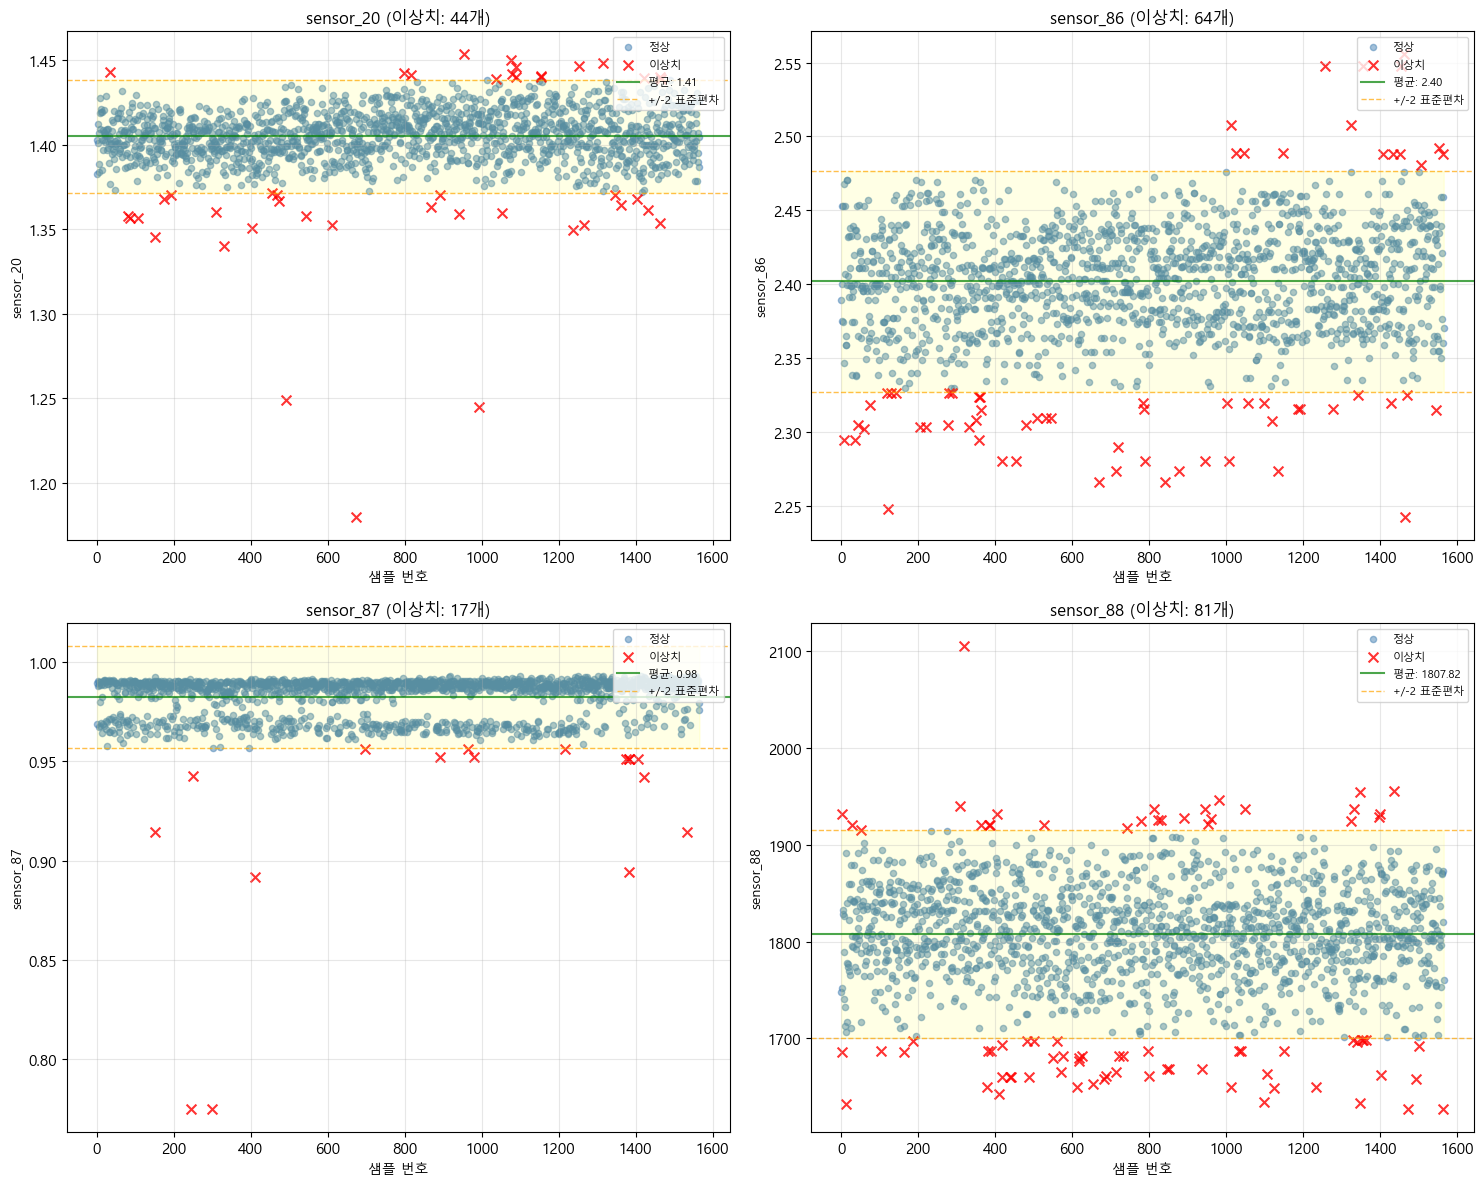

In [46]:
# 이상치 시각화 대시보드
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 분석 대상 센서 4개 선택
plot_sensors = analysis_cols[:4]

for idx, col in enumerate(plot_sensors):
    ax = axes[idx // 2, idx % 2]
    
    z_col = f'{col}_Z'
    outlier_col = f'{col}_outlier'
    
    # 정상 데이터
    normal_mask = ~result_df[outlier_col]
    ax.scatter(result_df.index[normal_mask], result_df[col][normal_mask],
               c='steelblue', alpha=0.5, s=20, label='정상')
    
    # 이상치
    outlier_mask = result_df[outlier_col]
    ax.scatter(result_df.index[outlier_mask], result_df[col][outlier_mask],
               c='red', alpha=0.8, s=50, marker='x', label='이상치')
    
    # 평균과 관리 한계선
    mean = result_df[col].mean()
    std = result_df[col].std()
    ax.axhline(mean, color='green', linestyle='-', linewidth=1.5, alpha=0.7, 
               label=f'평균: {mean:.2f}')
    ax.axhline(mean + 2*std, color='orange', linestyle='--', linewidth=1, 
               alpha=0.7, label='+/-2 표준편차')
    ax.axhline(mean - 2*std, color='orange', linestyle='--', linewidth=1, alpha=0.7)
    ax.fill_between(result_df.index, mean - 2*std, mean + 2*std, 
                    alpha=0.1, color='yellow')
    
    ax.set_xlabel('샘플 번호', fontsize=10)
    ax.set_ylabel(col, fontsize=10)
    outlier_count = outlier_mask.sum()
    ax.set_title(f'{col} (이상치: {outlier_count}개)', fontsize=12)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2.4 IQR 방법과 Z-score 비교

### IQR (Interquartile Range) 방법

**IQR 방법**은 분위수를 기반으로 이상치를 탐지하며, 정규분포 가정이 필요하지 않음.

#### 공식

$$\text{IQR} = Q_3 - Q_1$$

이상치 범위:
- **하한**: $Q_1 - 1.5 \times \text{IQR}$
- **상한**: $Q_3 + 1.5 \times \text{IQR}$

여기서:
- $Q_1$: 25번째 백분위수 (1사분위수)
- $Q_3$: 75번째 백분위수 (3사분위수)

### 두 방법 비교

| 비교 항목 | Z-score 방식 | IQR 방식 |
|----------|-------------|---------|
| **계산 기준** | 평균과 표준편차 | 사분위수 |
| **정규분포 가정** | 필요 | 불필요 |
| **이상치에 대한 강건성** | 낮음 (평균/표준편차가 영향받음) | 높음 (사분위수는 강건함) |
| **해석의 직관성** | 높음 (표준편차 단위) | 중간 |
| **적합한 분포** | 대칭 분포 | 모든 분포 |
| **기준** | 절대값 Z > 2 또는 3 | 1.5 x IQR 밖 |

이상치 탐지 방법 비교

[Z-score 방법] (|Z| > 2)
   평균: 1.4051
   표준편차: 0.0167
   하한: 1.3716
   상한: 1.4385
   이상치 개수: 44개

[IQR 방법] (1.5 x IQR)
   Q1: 1.3965
   Q3: 1.4150
   IQR: 0.0185
   하한: 1.3688
   상한: 1.4427
   이상치 개수: 29개

[공통 이상치]: 29개


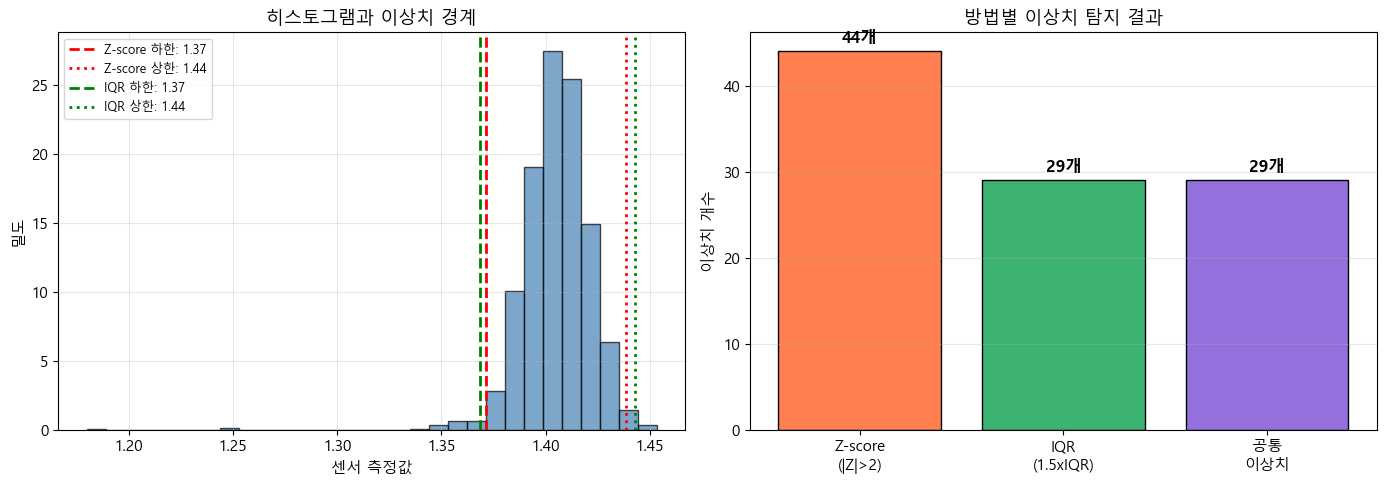


방법 선택 가이드:
   - 정규분포에 가까운 데이터: Z-score 방법 권장
   - 비대칭 또는 분포 형태 불확실: IQR 방법 권장
   - 엄격한 기준이 필요한 경우: 두 방법 모두 사용


In [47]:
def detect_outliers_iqr(data, k=1.5):
    """
    IQR 기반 이상치 탐지 함수
    
    Parameters
    ----------
    data : array-like
        분석할 데이터 배열
    k : float, default=1.5
        IQR 배수 (일반적으로 1.5 또는 3.0)
        
    Returns
    -------
    outlier_mask : ndarray of bool
        이상치 여부 (True: 이상치)
    bounds : dict
        경계값 정보
    """
    data = np.array(data)
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - k * IQR
    upper_bound = Q3 + k * IQR
    
    outlier_mask = (data < lower_bound) | (data > upper_bound)
    
    bounds = {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'k': k
    }
    
    return outlier_mask, bounds


# 두 방법 비교
sensor_col = selected_features[0]
sensor_values = df_secom[sensor_col].values

# Z-score 방법
outliers_z, z_scores, stats_z = detect_outliers_zscore(sensor_values, threshold=2)

# IQR 방법
outliers_iqr, bounds_iqr = detect_outliers_iqr(sensor_values, k=1.5)

print("이상치 탐지 방법 비교")
print("=" * 60)
print(f"\n[Z-score 방법] (|Z| > 2)")
print(f"   평균: {stats_z['mean']:.4f}")
print(f"   표준편차: {stats_z['std']:.4f}")
print(f"   하한: {stats_z['mean'] - 2*stats_z['std']:.4f}")
print(f"   상한: {stats_z['mean'] + 2*stats_z['std']:.4f}")
print(f"   이상치 개수: {np.sum(outliers_z)}개")

print(f"\n[IQR 방법] (1.5 x IQR)")
print(f"   Q1: {bounds_iqr['Q1']:.4f}")
print(f"   Q3: {bounds_iqr['Q3']:.4f}")
print(f"   IQR: {bounds_iqr['IQR']:.4f}")
print(f"   하한: {bounds_iqr['lower_bound']:.4f}")
print(f"   상한: {bounds_iqr['upper_bound']:.4f}")
print(f"   이상치 개수: {np.sum(outliers_iqr)}개")

# 공통 이상치
common_outliers = outliers_z & outliers_iqr
print(f"\n[공통 이상치]: {np.sum(common_outliers)}개")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히스토그램과 경계선
ax1 = axes[0]
ax1.hist(sensor_values, bins=30, density=True, alpha=0.7, 
         color='steelblue', edgecolor='black')

# Z-score 경계
mean = stats_z['mean']
std = stats_z['std']
ax1.axvline(mean - 2*std, color='red', linestyle='--', linewidth=2, 
            label=f'Z-score 하한: {mean-2*std:.2f}')
ax1.axvline(mean + 2*std, color='red', linestyle=':', linewidth=2,
            label=f'Z-score 상한: {mean+2*std:.2f}')

# IQR 경계
ax1.axvline(bounds_iqr['lower_bound'], color='green', linestyle='--', linewidth=2,
            label=f'IQR 하한: {bounds_iqr["lower_bound"]:.2f}')
ax1.axvline(bounds_iqr['upper_bound'], color='green', linestyle=':', linewidth=2,
            label=f'IQR 상한: {bounds_iqr["upper_bound"]:.2f}')

ax1.set_xlabel('센서 측정값', fontsize=11)
ax1.set_ylabel('밀도', fontsize=11)
ax1.set_title('히스토그램과 이상치 경계', fontsize=13)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# 방법별 이상치 개수 비교
ax2 = axes[1]
methods = ['Z-score\n(|Z|>2)', 'IQR\n(1.5xIQR)', '공통\n이상치']
counts = [np.sum(outliers_z), np.sum(outliers_iqr), np.sum(common_outliers)]
colors = ['coral', 'mediumseagreen', 'mediumpurple']

bars = ax2.bar(methods, counts, color=colors, edgecolor='black')
ax2.set_ylabel('이상치 개수', fontsize=11)
ax2.set_title('방법별 이상치 탐지 결과', fontsize=13)
ax2.grid(True, alpha=0.3, axis='y')

for bar, count in zip(bars, counts):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{count}개', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n방법 선택 가이드:")
print("   - 정규분포에 가까운 데이터: Z-score 방법 권장")
print("   - 비대칭 또는 분포 형태 불확실: IQR 방법 권장")
print("   - 엄격한 기준이 필요한 경우: 두 방법 모두 사용")

## 2.5 품질 그룹별 이상치 분석

SECOM 데이터에서 합격/불합격 그룹별로 이상치 분포를 비교함.

In [48]:
# 품질별 이상치 분석
print("품질 그룹별 이상치 분석")
print("=" * 60)

sensor_col = selected_features[0]

# 합격 그룹
pass_data = df_secom[df_secom['quality'] == -1][sensor_col].values
pass_outliers, _, pass_stats = detect_outliers_zscore(pass_data, threshold=2)

# 불합격 그룹
fail_data = df_secom[df_secom['quality'] == 1][sensor_col].values
fail_outliers, _, fail_stats = detect_outliers_zscore(fail_data, threshold=2)

print(f"\n분석 센서: {sensor_col}")
print(f"\n[합격 그룹]")
print(f"   데이터 수: {pass_stats['n_total']}개")
print(f"   평균: {pass_stats['mean']:.4f}")
print(f"   표준편차: {pass_stats['std']:.4f}")
print(f"   이상치: {pass_stats['n_outliers']}개 ({pass_stats['outlier_ratio']:.2f}%)")

print(f"\n[불합격 그룹]")
print(f"   데이터 수: {fail_stats['n_total']}개")
print(f"   평균: {fail_stats['mean']:.4f}")
print(f"   표준편차: {fail_stats['std']:.4f}")
print(f"   이상치: {fail_stats['n_outliers']}개 ({fail_stats['outlier_ratio']:.2f}%)")

# 평균 차이
mean_diff = fail_stats['mean'] - pass_stats['mean']
print(f"\n평균 차이 (불합격 - 합격): {mean_diff:.4f}")

품질 그룹별 이상치 분석

분석 센서: sensor_20

[합격 그룹]
   데이터 수: 1463개
   평균: 1.4050
   표준편차: 0.0169
   이상치: 42개 (2.87%)

[불합격 그룹]
   데이터 수: 104개
   평균: 1.4065
   표준편차: 0.0145
   이상치: 5개 (4.81%)

평균 차이 (불합격 - 합격): 0.0016


## 정리

### 핵심 개념

| 개념 | 정의 | 활용 |
|------|------|------|
| **Z-score** | $(X - \mu) / \sigma$, 표준화된 점수 | 이상치 판단의 기준 |
| **이상치 기준** | 절대값 Z > 2 (보수적) 또는 절대값 Z > 3 (일반적) | 품질 관리 |
| **IQR 방법** | $Q_3 - Q_1$ 기반, 1.5 x IQR 밖 = 이상치 | 비정규 분포 데이터 |

### 핵심 공식

$$Z = \frac{X - \mu}{\sigma}$$

$$\text{IQR 이상치 범위: } [Q_1 - 1.5 \times \text{IQR}, \; Q_3 + 1.5 \times \text{IQR}]$$

### 방법 선택 가이드

- **정규분포**: Z-score 방법
- **비대칭/불확실**: IQR 방법
- **엄격한 기준**: 두 방법 병행

# 통계 검정 방법 개요: 상황별 검정법 선택 가이드

t-검정을 본격적으로 학습하기 전에, 제조 현장에서 마주칠 수 있는 다양한 통계적 질문에 어떤 검정 방법을 적용해야 하는지 체계적으로 정리함.

## 3.1 가설검정의 개념

### 제조 현장의 질문들

| 질문 | 비교 대상 | 검정 방법 |
|------|----------|----------|
| "새 공정이 불량률을 줄였을까?" | 개선 전 vs 개선 후 | 대응표본 t-검정 |
| "라인 A와 라인 B의 품질 차이가 있을까?" | 라인 A vs 라인 B | 독립표본 t-검정 |
| "새 원료로 품질이 나아졌을까?" | 기존 원료 vs 신규 원료 | 독립표본 t-검정 |
| "3개 공장의 불량률 차이가 있을까?" | 공장 A vs B vs C | ANOVA |

### 문제의 핵심

데이터에서 차이가 보여도, 그것이 **진짜 차이**인지 **우연**인지 구분해야 함.

---

## 3.2 가설의 종류

### 귀무가설과 대립가설

#### 귀무가설 (H0: Null Hypothesis)
- "**차이가 없다**" 또는 "**효과가 없다**"는 가설
- 기각되기를 기대하는 가설
- 예: "두 라인의 불량률은 같다"

#### 대립가설 (H1 또는 Ha: Alternative Hypothesis)
- "**차이가 있다**" 또는 "**효과가 있다**"는 가설
- 증명하고 싶은 가설
- 예: "두 라인의 불량률은 다르다"

### 수학적 표현

#### 양측검정 (Two-tailed test)
- $H_0: \mu_A = \mu_B$ (또는 $\mu_A - \mu_B = 0$)
- $H_1: \mu_A \neq \mu_B$ (또는 $\mu_A - \mu_B \neq 0$)

#### 단측검정 (One-tailed test)
- 왼쪽 단측: $H_0: \mu_A \geq \mu_B$, $H_1: \mu_A < \mu_B$
- 오른쪽 단측: $H_0: \mu_A \leq \mu_B$, $H_1: \mu_A > \mu_B$

검정의 기본 전략: "귀무가설이 틀렸음을 증명"하면 대립가설을 채택함.

## 3.3 p-value의 이해

### p-value의 정의

$$\text{p-value} = P(\text{관측된 차이 이상} \mid H_0 \text{가 참})$$

**p-value**는 귀무가설이 참일 때, 관측된 결과(또는 그보다 극단적인 결과)가 우연히 나타날 확률임.

### p-value 해석

| p-value | 해석 | 귀무가설에 대한 결론 |
|---------|------|---------------------|
| p < 0.01 | 매우 강한 증거 | 기각 (매우 확실) |
| p < 0.05 | 강한 증거 | 기각 |
| 0.05 <= p < 0.10 | 약한 증거 | 경계선 |
| p >= 0.10 | 증거 부족 | 기각하지 못함 |

### 유의수준 (alpha, Significance Level)

**유의수준**은 귀무가설을 기각하기 위한 판단 기준임.

| 유의수준 | 의미 | 사용 상황 |
|---------|------|----------|
| alpha = 0.05 (5%) | 가장 널리 사용 | 일반적인 연구 |
| alpha = 0.01 (1%) | 엄격한 기준 | 중요한 의사결정 |
| alpha = 0.10 (10%) | 느슨한 기준 | 탐색적 분석 |

### 판단 규칙

$$
\begin{cases}
p < \alpha & \Rightarrow \text{귀무가설 기각} \Rightarrow \text{"차이가 있다"} \\
p \geq \alpha & \Rightarrow \text{귀무가설 기각 못함} \Rightarrow \text{"차이가 있다고 말할 수 없다"}
\end{cases}
$$

**주의**: p >= alpha라고 해서 "차이가 없다"는 것이 아님. 정확한 해석은 "차이가 있다는 **충분한 증거가 없다**"임.


## 검정 방법 선택의 핵심 기준

통계 검정 방법을 선택할 때는 다음 **4가지 질문**에 답해야 함:

1. **비교 대상의 수**: 1개, 2개, 3개 이상인가?
2. **변수의 유형**: 연속형(수치형)인가, 범주형(명목형)인가?
3. **데이터의 분포**: 정규분포를 따르는가? (모수적 vs 비모수적)
4. **표본의 관계**: 독립적인가, 대응(짝지어진)인가?

## 주요 통계 검정 방법 종합표

### 연속형 변수(수치형 데이터)의 검정

| 검정 방법 | 비교 대상 | 정규성 가정 | 사용 조건 | 제조 현장 예시 |
|----------|----------|------------|----------|---------------|
| **단일표본 t-검정** | 1개 그룹 vs 기준값 | 필요 | 표본평균이 특정 기준값과 같은지 검정 | "평균 생산량이 목표(1,200개)와 같은가?" |
| **독립표본 t-검정** | 2개 독립 그룹 | 필요 | 두 독립 그룹의 평균 비교 | "라인 A와 라인 B의 불량률이 다른가?" |
| **대응표본 t-검정** | 2개 대응 그룹 | 필요 | 동일 대상의 전후 비교 | "공정 개선 전후 불량률이 달라졌는가?" |
| **일원배치 ANOVA** | 3개+ 독립 그룹 | 필요 | 3개 이상 그룹의 평균 비교 | "3개 공장의 불량률이 다른가?" |
| **반복측정 ANOVA** | 3개+ 대응 측정 | 필요 | 동일 대상의 여러 시점 비교 | "월별 품질 추이가 유의미하게 변하는가?" |
| **Mann-Whitney U** | 2개 독립 그룹 | 불필요 | 비정규 분포, 순위 데이터 | "두 교대조의 생산성 차이가 있는가?" |
| **Wilcoxon 부호순위** | 2개 대응 그룹 | 불필요 | 비정규 분포의 전후 비교 | "설비 교체 전후 고장 빈도 차이가 있는가?" |
| **Kruskal-Wallis** | 3개+ 독립 그룹 | 불필요 | 비정규 분포의 다중 그룹 비교 | "4개 원자재 공급사별 품질 차이가 있는가?" |

### 범주형 변수(명목형 데이터)의 검정

| 검정 방법 | 목적 | 사용 조건 | 제조 현장 예시 |
|----------|------|----------|---------------|
| **카이제곱 적합도 검정** | 관측 빈도 vs 기대 빈도 | 각 셀 기대빈도 >= 5 | "불량 유형 분포가 과거와 같은가?" |
| **카이제곱 독립성 검정** | 두 범주형 변수의 관련성 | 각 셀 기대빈도 >= 5 | "교대조와 불량 발생이 관련 있는가?" |
| **Fisher 정확 검정** | 두 범주형 변수의 관련성 | 소표본 (기대빈도 < 5) | "소량 생산에서 원료와 불량의 관계가 있는가?" |
| **McNemar 검정** | 대응 이진 데이터 비교 | 동일 대상의 전후 이진 결과 | "검사 방법 변경 후 합격/불합격 비율 변화가 있는가?" |

### 사전 검정 (가정 확인용)

| 검정 방법 | 목적 | 귀무가설 | 해석 |
|----------|------|---------|------|
| **Shapiro-Wilk 검정** | 정규성 검정 | "데이터가 정규분포를 따른다" | p > 0.05이면 정규분포 가정 충족 |
| **Kolmogorov-Smirnov 검정** | 정규성 검정 | "데이터가 정규분포를 따른다" | p > 0.05이면 정규분포 가정 충족 |
| **Levene 검정** | 등분산 검정 | "두 그룹의 분산이 같다" | p > 0.05이면 등분산 가정 충족 |
| **Bartlett 검정** | 등분산 검정 | "모든 그룹의 분산이 같다" | p > 0.05이면 등분산 가정 충족 |


## 검정 방법 선택 의사결정 흐름도

```
                            +-------------------------+
                            |    분석하려는 변수의    |
                            |       유형은?          |
                            +-----------+-------------+
                                        |
                    +-------------------+-------------------+
                    v                                       v
            +---------------+                       +---------------+
            |   연속형      |                       |   범주형      |
            |  (수치 데이터) |                       |  (빈도 데이터) |
            +-------+-------+                       +-------+-------+
                    |                                       |
                    v                                       v
        +-----------------------+               +-----------------------+
        |  정규분포를 따르는가?  |               |  기대빈도 >= 5인가?   |
        +-----------+-----------+               +-----------+-----------+
                    |                                       |
            +-------+-------+                       +-------+-------+
            v               v                       v               v
        +-------+       +-------+               +-------+       +-------+
        |  예   |       | 아니오 |               |  예   |       | 아니오 |
        |(모수적)|       |(비모수)|               |       |       |       |
        +---+---+       +---+---+               +---+---+       +---+---+
            |               |                       |               |
            v               v                       v               v
    +-----------+   +-----------+           +-----------+   +-----------+
    |비교그룹수?|   |비교그룹수?|           | 카이제곱  |   |  Fisher   |
    +-----+-----+   +-----+-----+           |  검정    |   | 정확 검정  |
          |               |                 +-----------+   +-----------+
    +--+--+--+     +--+--+--+
    v  v     v     v  v     v
   1개 2개  3개+  2개 2개  3개+
    |  |     |     |  |     |
    v  v     v     v  v     v
  단일 독립/ 일원  Mann- Wilcoxon Kruskal-
  표본 대응  배치  Whitney 부호순위 Wallis
  t검정 t검정 ANOVA U검정   검정    검정
```

## 모수적 검정 vs 비모수적 검정

### 개념 비교

| 구분 | 모수적 검정 (Parametric) | 비모수적 검정 (Non-parametric) |
|------|-------------------------|-------------------------------|
| **정의** | 모집단이 특정 분포(주로 정규분포)를 따른다고 가정함 | 분포 가정 없이 순위나 빈도 기반임 |
| **가정** | 정규성, 등분산성 등 엄격한 가정 필요 | 최소한의 가정만 필요 |
| **검정력** | 가정 충족 시 더 높은 검정력 보유 | 상대적으로 낮은 검정력 |
| **적용** | 대표본, 정규분포 데이터 | 소표본, 비정규분포, 순위 데이터 |
| **예시** | t-검정, ANOVA, Pearson 상관 | Mann-Whitney, Kruskal-Wallis, Spearman 상관 |

### 대응 관계

| 모수적 검정 | 비모수적 대안 | 사용 상황 |
|------------|-------------|----------|
| 단일표본 t-검정 | Wilcoxon 부호순위 검정 | 1개 그룹 vs 기준값 |
| 독립표본 t-검정 | Mann-Whitney U 검정 | 2개 독립 그룹 비교 |
| 대응표본 t-검정 | Wilcoxon 부호순위 검정 | 동일 대상 전후 비교 |
| 일원배치 ANOVA | Kruskal-Wallis 검정 | 3개+ 그룹 비교 |
| Pearson 상관계수 | Spearman 순위상관 | 두 변수 간 관계 |

## Python SciPy 검정 함수 요약

| 검정 방법 | SciPy 함수 | 주요 파라미터 |
|----------|-----------|--------------|
| 단일표본 t-검정 | `stats.ttest_1samp(a, popmean)` | `a`: 데이터, `popmean`: 비교 기준값 |
| 독립표본 t-검정 | `stats.ttest_ind(a, b, equal_var)` | `equal_var=False`: Welch's t-test |
| 대응표본 t-검정 | `stats.ttest_rel(a, b)` | `a`, `b`: 대응 데이터 |
| 일원배치 ANOVA | `stats.f_oneway(*groups)` | 가변 인자로 그룹 전달 |
| Mann-Whitney U | `stats.mannwhitneyu(x, y)` | `alternative`: 단측/양측 |
| Wilcoxon 부호순위 | `stats.wilcoxon(x, y)` | `x`, `y`: 대응 데이터 |
| Kruskal-Wallis | `stats.kruskal(*groups)` | 가변 인자로 그룹 전달 |
| 카이제곱 독립성 | `stats.chi2_contingency(table)` | `table`: 분할표 |
| Fisher 정확 | `stats.fisher_exact(table)` | 2x2 분할표만 가능 |
| Shapiro-Wilk | `stats.shapiro(x)` | 정규성 검정 |
| Levene | `stats.levene(*groups)` | 등분산 검정 |

## 검정 결과 해석 시 주의사항

### 1. p-value의 올바른 해석

| p-value 결과 | 올바른 해석 | 잘못된 해석 |
|-------------|------------|------------|
| p < 0.05 | "귀무가설을 기각할 충분한 증거가 있음" | "차이가 있다고 100% 확신함" |
| p >= 0.05 | "귀무가설을 기각할 충분한 증거가 없음" | "차이가 없음" |

### 2. 통계적 유의성 vs 실질적 유의성

**"통계적으로 유의미함"이 "실질적으로 의미있음"과 동일하지 않음.**

- 표본 크기가 크면 작은 차이도 통계적으로 유의미해질 수 있음
- 반드시 **효과 크기(Effect Size)** 를 함께 확인해야 함

### 3. 다중 비교 문제

3개 이상 그룹을 비교할 때 t-검정을 여러 번 수행하면 제1종 오류율이 증가함.

In [49]:
def familywise_error_rate(alpha, n_comparisons):
    """
    다중 비교 시 가족별 오류율(FWER) 계산
    
    FWER = 1 - (1 - alpha)^k
    
    Parameters
    ----------
    alpha : float
        개별 검정의 유의수준
    n_comparisons : int
        비교 횟수
        
    Returns
    -------
    float : 가족별 오류율
    """
    fwer = 1 - (1 - alpha)**n_comparisons
    return fwer


print("다중 비교 시 제1종 오류율 증가")
print("=" * 50)
print(f"개별 검정 유의수준: alpha = 0.05\n")

for n_groups in [2, 3, 4, 5, 6]:
    n_comparisons = n_groups * (n_groups - 1) // 2  # 조합 수
    fwer = familywise_error_rate(0.05, n_comparisons)
    print(f"{n_groups}개 그룹 ({n_comparisons}회 비교): FWER = {fwer:.1%}")

print("\n해결책:")
print("   1. ANOVA 사용 (3개+ 그룹 비교)")
print("   2. Bonferroni 보정: alpha' = alpha / k")
print("   3. 사후검정: Tukey HSD, Scheffe 등")

다중 비교 시 제1종 오류율 증가
개별 검정 유의수준: alpha = 0.05

2개 그룹 (1회 비교): FWER = 5.0%
3개 그룹 (3회 비교): FWER = 14.3%
4개 그룹 (6회 비교): FWER = 26.5%
5개 그룹 (10회 비교): FWER = 40.1%
6개 그룹 (15회 비교): FWER = 53.7%

해결책:
   1. ANOVA 사용 (3개+ 그룹 비교)
   2. Bonferroni 보정: alpha' = alpha / k
   3. 사후검정: Tukey HSD, Scheffe 등


## 실무 체크리스트

통계 검정을 수행하기 전에 다음 사항을 확인해야 함:

- [ ] **1. 연구 질문 명확화**: 무엇을 비교/검정하려는가?
- [ ] **2. 변수 유형 확인**: 연속형인가, 범주형인가?
- [ ] **3. 그룹 수 확인**: 1개, 2개, 3개 이상인가?
- [ ] **4. 표본 관계 확인**: 독립인가, 대응(짝지어진)인가?
- [ ] **5. 정규성 검정**: Shapiro-Wilk 등으로 확인
- [ ] **6. 등분산 검정**: Levene 등으로 확인 (t-검정, ANOVA 시)
- [ ] **7. 표본 크기 확인**: 소표본이면 비모수 검정 고려
- [ ] **8. 효과 크기 계산**: Cohen's d, 에타 제곱 등
- [ ] **9. 결과 해석**: p-value와 효과 크기 함께 보고

## 정리

### 핵심 개념

| 개념 | 정의 | 활용 |
|------|------|------|
| **가설검정** | 데이터로 주장을 검증하는 통계적 방법 | 차이/효과의 유의성 확인 |
| **p-value** | 귀무가설이 참일 때 관측 결과가 우연일 확률 | 유의성 판단 기준 |
| **t-검정** | 두 그룹의 평균 비교 | 라인 비교, 전후 비교 |
| **효과 크기** | 차이의 실질적 크기 (Cohen's d) | p-value 보완 |
| **ANOVA** | 3개 이상 그룹의 평균 비교 | 다중 그룹 비교 |

### 핵심 공식

**t-통계량:**
$$t = \frac{\bar{X}_1 - \bar{X}_2}{s_p \sqrt{\frac{1}{n_1} + \frac{1}{n_2}}}$$

**Cohen's d:**
$$d = \frac{\bar{X}_1 - \bar{X}_2}{s_p}$$

### 판단 기준

| p-value | 결론 |
|---------|------|
| p < 0.05 | 통계적으로 유의미한 차이 있음 |
| p >= 0.05 | 유의미한 차이 있다고 말할 수 없음 |

| Cohen's d | 효과 크기 |
|-----------|----------|
| < 0.2 | 작은 효과 |
| 0.5 | 중간 효과 |
| > 0.8 | 큰 효과 |